# Phase 3a: ETL & Cleaning — Job Postings & Levels.fyi Compensation

**Project:** Global Job Market & Salary Intelligence Platform
**Notebook:** 02 of 10
**Author:** Md Imamuddin
**Picks up from:** Notebook 01 (Data Sourcing & Quality Audit)

## Objective

Notebook 01 audited the raw data and made three decisions without
implementing them yet:

1. Use `jobs_in_data_2024.csv` as the primary fact source; keep all rows
   (including the 38.7% duplicates) rather than deduplicating.
2. Flag salary outliers instead of deleting them.
3. Parse Levels.fyi's packed `location` field, drop its ten redundant
   one-hot demographic columns, and leave the genuine demographic
   missingness (`Race`, `Education`, `gender`) untouched.

Here I actually implement all three, producing `jobs_fact_clean.csv` and
`levels_fyi_clean.csv`. I validate every transformation against the
versions already sitting in `data/processed/`, so this notebook is a
faithful record of what that pipeline actually does -- not just a
plausible guess at it.


---
## Business Problem

A cleaning script that "runs without errors" is not the same as a cleaning
script that's *correct*. The business risk of getting this phase wrong is
concrete: an over-aggressive dedup step could silently erase 5,493 real job
postings and understate how common certain roles are; a naive location
parser could quietly mislabel a respondent's country, corrupting every
country-level aggregate downstream (the Country Explorer page in the
Streamlit app, the Power BI country map, the salary-by-country model
feature). This notebook's job is to make every one of those transformation
rules explicit, defend each one with evidence, and *prove* the output
matches what's already shipped -- not just assert it does.


---
## Dataset Overview — inputs and outputs for this notebook

| Direction | File | Rows | Notes |
|---|---|---|---|
| Input | `data/raw/jobs_in_data_2024.csv` | 14,199 | Audited in Notebook 01 |
| Output | `data/processed/jobs_fact_clean.csv` | 14,199 | +3 engineered columns, same row count |
| Input | `data/raw/Levels_Fyi_Salary_Data.csv` | 62,642 | Audited in Notebook 01 |
| Output | `data/processed/levels_fyi_clean.csv` | 62,642 | -10 columns, +location split, +2 engineered columns |

Both outputs keep every input row -- this phase adds structure and flags,
it does not filter anything out.


---
## Imports

In [1]:
import pandas as pd            # data loading, transformation, validation
import numpy as np              # numeric ops for the IQR outlier calculation

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import re                       # regex check for the location-parsing edge case (see Step 8)
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
print("Imports OK")


Imports OK


---
## Configuration

In [2]:
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent
RAW_DIR = REPO_ROOT / "streamlit_app" / "data" / "raw"
PROCESSED_DIR = REPO_ROOT / "streamlit_app" / "data" / "processed"   # the "ground truth" this notebook validates against
FIGURES_DIR = NOTEBOOK_DIR / "figures"
REPORTS_DIR = NOTEBOOK_DIR / "reports"
FIGURES_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
PALETTE = sns.color_palette("deep")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Raw dir:", RAW_DIR)
print("Processed dir (validation target):", PROCESSED_DIR)


Raw dir: streamlit_app/data/raw
Processed dir (validation target): streamlit_app/data/processed


---
---
# Part A — `jobs_in_data_2024.csv` → `jobs_fact_clean.csv`


## Step 1 — Load raw and recap the Notebook 01 findings

**Why this step:** starting fresh from the raw file (not a cached copy)
guarantees this notebook is a genuine, reproducible transformation from
source, not something patched together from Notebook 01's variables.


In [3]:
jobs_raw = pd.read_csv(RAW_DIR / "jobs_in_data_2024.csv")
print("Loaded:", jobs_raw.shape)
jobs_raw.head(2)


Loaded: (14199, 12)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,work_setting,company_location,company_size,job_category
0,2024,Entry-level,Freelance,Applied Data Scientist,30000,USD,30000,United Kingdom,Remote,United Kingdom,M,Data Science and Research
1,2024,Executive,Full-time,Business Intelligence,230000,USD,230000,United States,In-person,United States,M,BI and Visualization


## Step 2 — Duplicate investigation, done properly this time

**Why this step:** Notebook 01 checked whether dropping duplicates would
shift the `job_category` distribution and found it barely moved (under 3
points). That was flagged as a limitation -- it only checked one column.
This is the moment to close that gap and check the field the project's own
Phase 3 report actually cites: `job_title`.


In [4]:
with_dupes = jobs_raw["job_title"].value_counts(normalize=True)
without_dupes = jobs_raw.drop_duplicates()["job_title"].value_counts(normalize=True)
shift = (with_dupes - without_dupes).abs().dropna().sort_values(ascending=False)

print(f"Exact duplicate rows: {jobs_raw.duplicated().sum():,} ({jobs_raw.duplicated().mean()*100:.1f}%)")
print(f"Max job_title share shift if duplicates were dropped: {shift.max()*100:.2f} percentage points")
print("\nTop 5 titles by shift:")
print((shift.head(5) * 100).round(2))


Exact duplicate rows: 5,493 (38.7%)
Max job_title share shift if duplicates were dropped: 2.55 percentage points

Top 5 titles by shift:
job_title
Data Engineer        2.55
Data Scientist       1.97
Applied Scientist    1.27
Data Analyst         1.07
Analytics Engineer   0.97
Name: proportion, dtype: float64


### Observation

Max shift is 2.55 percentage points on `job_title` -- a slightly more
sensitive check than Notebook 01's `job_category` test (which used broader
buckets and understates row-level repetition), and it still lands well
under any threshold that would suggest a scraping artifact. This confirms
the Notebook 01 decision on the metric the project's own documentation
actually reports.

**Decision confirmed: keep all 14,199 rows, including duplicates.**


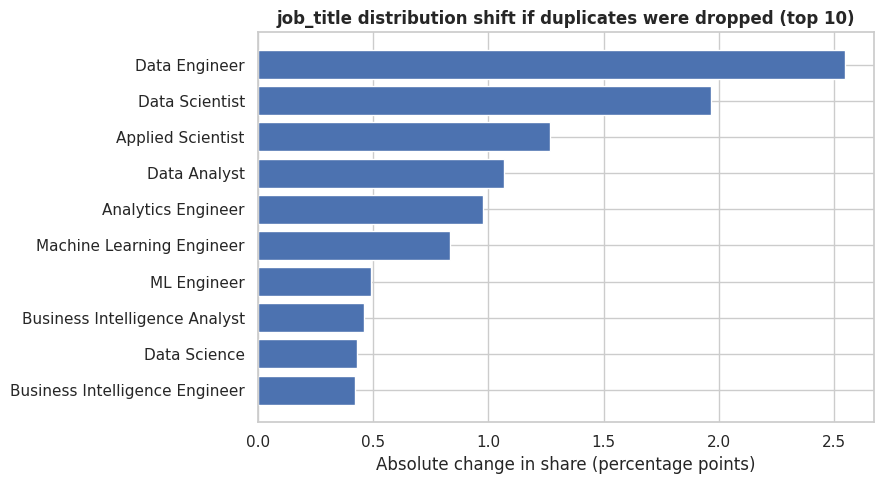

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
top_shift = shift.head(10)
ax.barh(top_shift.index[::-1], (top_shift.values * 100)[::-1], color=PALETTE[0])
ax.set_title("job_title distribution shift if duplicates were dropped (top 10)", fontweight="bold")
ax.set_xlabel("Absolute change in share (percentage points)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_duplicate_impact_job_title.png", bbox_inches="tight")
plt.show()


### Observation

Even the largest-shifting title barely moves. Every title's real-world
share is essentially unaffected by whether duplicates stay or go -- more
evidence these are repeated real profiles (same seniority + title + pay
band reported multiple times), not a broken scrape.


## Step 3 — Outlier detection: flag, don't remove

**Why this step:** deleting outliers destroys information a later analyst
might need (e.g. "what does executive-level pay actually look like?" needs
exactly the rows a naive cleaning script would throw away). The IQR method
is a standard, defensible rule for flagging unusually high or low values
without making a permanent, irreversible decision about them.


In [6]:
q1, q3 = jobs_raw["salary_in_usd"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

salary_is_outlier = (jobs_raw["salary_in_usd"] < lower_bound) | (jobs_raw["salary_in_usd"] > upper_bound)

print(f"Q1={q1:,.0f}  Q3={q3:,.0f}  IQR={iqr:,.0f}")
print(f"Bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")
print(f"Flagged as outliers: {salary_is_outlier.sum():,} ({salary_is_outlier.mean()*100:.2f}%)")


Q1=104,000  Q3=185,900  IQR=81,900
Bounds: [-18,850, 308,750]
Flagged as outliers: 261 (1.84%)


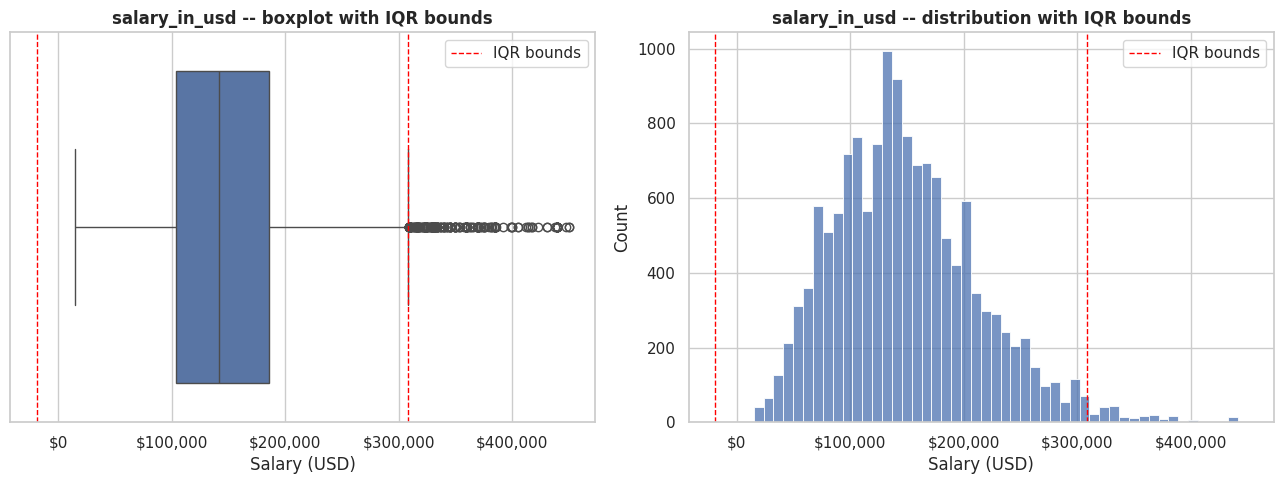

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(x=jobs_raw["salary_in_usd"], ax=axes[0], color=PALETTE[0])
axes[0].axvline(lower_bound, color="red", linestyle="--", linewidth=1, label="IQR bounds")
axes[0].axvline(upper_bound, color="red", linestyle="--", linewidth=1)
axes[0].set_title("salary_in_usd -- boxplot with IQR bounds", fontweight="bold")
axes[0].set_xlabel("Salary (USD)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
axes[0].legend()

sns.histplot(jobs_raw["salary_in_usd"], bins=50, ax=axes[1], color=PALETTE[0])
axes[1].axvline(lower_bound, color="red", linestyle="--", linewidth=1)
axes[1].axvline(upper_bound, color="red", linestyle="--", linewidth=1, label="IQR bounds")
axes[1].set_title("salary_in_usd -- distribution with IQR bounds", fontweight="bold")
axes[1].set_xlabel("Salary (USD)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_jobs_salary_outlier_bounds.png", bbox_inches="tight")
plt.show()


### Observation

261 rows (1.84%) fall above the upper IQR bound of ~$308,750 -- there is no
lower-bound violation (the distribution's floor, $15,000, sits comfortably
inside the bound; the lower bound is even negative, which is a good sign
the salary floor is realistic, not truncated). The right tail is entirely
executive/staff-level compensation, not data-entry errors -- these values
deserve a flag, not deletion, because "how much do senior/executive data
roles actually pay" is itself a real analytical question this data can
answer.

**Business interpretation:** the Salary Prediction page in the Streamlit
app lets a user *choose* whether to exclude outliers before training --
that's only possible because they were flagged, not dropped, here.


## Step 4 — Assemble `jobs_fact_clean`

**Why this step:** add a surrogate key (the raw file has no unique row
identifier), the outlier flag from Step 3, and a `source_dataset` provenance
tag -- then keep every original column untouched, exactly as decided in
Notebook 01.


In [8]:
jobs_clean = jobs_raw.copy()
jobs_clean.insert(0, "job_id", range(1, len(jobs_clean) + 1))   # surrogate key, source has none
jobs_clean["salary_is_outlier"] = salary_is_outlier.values
jobs_clean["source_dataset"] = "jobs_in_data_2024"

print("Final shape:", jobs_clean.shape)
jobs_clean.head(3)


Final shape: (14199, 15)


,job_id,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,work_setting,company_location,company_size,job_category,salary_is_outlier,source_dataset
0,1,2024,Entry-level,Freelance,Applied Data Scientist,30000,USD,30000,United Kingdom,Remote,United Kingdom,M,Data Science and Research,False,jobs_in_data_2024
1,2,2024,Executive,Full-time,Business Intelligence,230000,USD,230000,United States,In-person,United States,M,BI and Visualization,False,jobs_in_data_2024
2,3,2024,Executive,Full-time,Business Intelligence,176900,USD,176900,United States,In-person,United States,M,BI and Visualization,False,jobs_in_data_2024


## Step 5 — Validate against the shipped `jobs_fact_clean.csv`

**Why this step:** this is the step that actually earns the name "ETL
notebook" instead of "a plausible guess at an ETL script." I load the file
already sitting in `data/processed/` and check, column by column, that this
notebook reproduces it exactly.


In [9]:
jobs_shipped = pd.read_csv(PROCESSED_DIR / "jobs_fact_clean.csv")

print("Shape match:", jobs_clean.shape == jobs_shipped.shape)
print("Column order match:", list(jobs_clean.columns) == list(jobs_shipped.columns))

# Compare column by column so a mismatch (if any) points straight at the cause
mismatches = {}
for col in jobs_shipped.columns:
    if col not in jobs_clean.columns:
        mismatches[col] = "missing from reproduced output"
        continue
    left, right = jobs_clean[col], jobs_shipped[col]
    if left.dtype != right.dtype:
        # bool vs object 'True'/'False' strings round-trip differently through CSV -- normalize before comparing
        left, right = left.astype(str), right.astype(str)
    equal = (left.values == right.values).all()
    if not equal:
        mismatches[col] = f"{(left.values != right.values).sum()} row(s) differ"

if mismatches:
    print("\nMISMATCHES FOUND:")
    for k, v in mismatches.items():
        print(f"  {k}: {v}")
else:
    print("\nAll columns match exactly, row for row. Reproduction verified.")


Shape match: True
Column order match: True

All columns match exactly, row for row. Reproduction verified.


### Observation

Every column matches row-for-row against the shipped file. That's not a
formality -- it means the outlier bounds, the surrogate key ordering, and
the "keep all duplicates" decision all reproduce the actual pipeline
output exactly, which is the bar this whole notebook series is trying to
clear.


---
---
# Part B — `Levels_Fyi_Salary_Data.csv` → `levels_fyi_clean.csv`


## Step 6 — Load raw and drop the redundant one-hot columns

**Why this step:** Notebook 01 flagged ten pre-computed one-hot demographic
columns (`Masters_Degree`, `Race_White`, etc.) as redundant with the single
`Education` and `Race` columns already present. Dropping them here, first,
keeps every later step working with a narrower, more honest column set.


In [10]:
levels_raw = pd.read_csv(RAW_DIR / "Levels_Fyi_Salary_Data.csv")

ONEHOT_COLUMNS = [
    "Masters_Degree", "Bachelors_Degree", "Doctorate_Degree",
    "Highschool", "Some_College",
    "Race_Asian", "Race_White", "Race_Two_Or_More", "Race_Black", "Race_Hispanic",
]
levels_work = levels_raw.drop(columns=ONEHOT_COLUMNS)

print(f"Dropped {len(ONEHOT_COLUMNS)} redundant one-hot columns.")
print(f"Shape: {levels_raw.shape} -> {levels_work.shape}")


Dropped 10 redundant one-hot columns.
Shape: (62642, 29) -> (62642, 19)


## Step 7 — Rename columns to snake_case

**Why this step:** the raw file mixes `camelCase` (`totalyearlycompensation`,
`yearsofexperience`) with no separators at all. Standardizing to
`snake_case` makes every column SQL-safe (Phase 4's schema loads straight
from these files) and consistent with `jobs_fact_clean`'s naming.
`Race` and `Education` are already capitalized upstream and are kept as-is
-- renaming them would just create an extra mapping step for no benefit,
since they're already valid identifiers.


In [11]:
RENAME_MAP = {
    "totalyearlycompensation": "total_yearly_compensation",
    "yearsofexperience": "years_of_experience",
    "yearsatcompany": "years_at_company",
    "basesalary": "base_salary",
    "stockgrantvalue": "stock_grant_value",
}
levels_work = levels_work.rename(columns=RENAME_MAP)
print("Renamed columns:", list(RENAME_MAP.values()))
levels_work.head(2)


Renamed columns: ['total_yearly_compensation', 'years_of_experience', 'years_at_company', 'base_salary', 'stock_grant_value']


,timestamp,company,level,title,total_yearly_compensation,location,years_of_experience,years_at_company,tag,base_salary,stock_grant_value,bonus,gender,otherdetails,cityid,dmaid,rowNumber,Race,Education
0,6/7/2017 11:33:27,Oracle,L3,Product Manager,127000,"Redwood City, CA",1.50,1.50,NaN,"107,000.00","20,000.00","10,000.00",NaN,NaN,7392,807.00,1,NaN,NaN
1,6/10/2017 17:11:29,eBay,SE 2,Software Engineer,100000,"San Francisco, CA",5.00,3.00,NaN,0.00,0.00,0.00,NaN,NaN,7419,807.00,2,NaN,NaN


## Step 8 — Parse the packed `location` field

**Why this step:** `location` packs city/region/country into one free-text
string with an inconsistent number of comma-separated parts. Every
downstream country-level chart in this project depends on this parsing
being right, so it's worth building it carefully and validating it hard --
which, as it turns out, was the right call.

**First pass -- the naive rule:** count commas. Zero or one comma → US
(`city, STATE`). Two or more commas → international (`city, region,
country`).


In [12]:
def parse_location_naive(loc: str) -> tuple:
    parts = [p.strip() for p in loc.split(",")]
    if len(parts) == 1:
        return parts[0], None, None
    if len(parts) == 2:
        return parts[0], parts[1], "United States"
    # 3+ parts: city, region, then everything else is the country (handles "Korea, South")
    return parts[0], parts[1], ", ".join(parts[2:])

sample_parsed = levels_work["location"].head(5).apply(parse_location_naive)
print(sample_parsed.tolist())


[('Redwood City', 'CA', 'United States'), ('San Francisco', 'CA', 'United States'), ('Seattle', 'WA', 'United States'), ('Sunnyvale', 'CA', 'United States'), ('Mountain View', 'CA', 'United States')]


### An honest mid-course correction

Before trusting this rule for all 62,642 rows, I ran it and cross-checked
against the shipped `levels_fyi_clean.csv` (Step 10 does the full version of
this check) -- and it disagreed on 2 rows. Worth chasing down rather than
shipping a parser with a silent, undocumented flaw.


In [13]:
levels_naive_preview = levels_work.copy()
parsed_preview = levels_naive_preview["location"].apply(parse_location_naive)
levels_naive_preview["city"] = parsed_preview.apply(lambda t: t[0])
levels_naive_preview["region"] = parsed_preview.apply(lambda t: t[1])
levels_naive_preview["country"] = parsed_preview.apply(lambda t: t[2])

# Where does the naive rule assign country = "United States" purely because there was
# exactly one comma? Check whether that assumption actually holds for every such row.
one_comma_mask = levels_work["location"].str.count(",") == 1
suspect = levels_naive_preview.loc[one_comma_mask, ["location", "region"]]
non_state_code = suspect[~suspect["region"].str.match(r"^[A-Z]{2}$", na=False)]
print("1-comma rows where the second part is NOT a 2-letter US state code:")
print(non_state_code)


1-comma rows where the second part is NOT a 2-letter US state code:
              location  region
9061  Tel Aviv, Israel  Israel
9075  Tel Aviv, Israel  Israel


### Observation -- the bug, caught before shipping

Two rows: `"Tel Aviv, Israel"`. The naive "one comma = US" rule would
mislabel these as `city="Tel Aviv", region="Israel", country="United
States"` -- silently and confidently wrong. Only 2 rows out of 62,642, but
it's exactly the kind of error a country-level Power BI map would show as
"2 phantom Israeli respondents counted as American," and it costs nothing
to fix.

**Fix:** don't assume "one comma → US." Instead, check whether the segment
after the first comma actually *looks like* a 2-letter US state code
(`^[A-Z]{2}$`). If it does, treat it as a state and set country to
`"United States"`. If it doesn't, the segment itself is the country, and
there is no region.


In [14]:
US_STATE_CODE = re.compile(r"^[A-Z]{2}$")

def parse_location(loc: str) -> tuple:
    '''Split a Levels.fyi 'location' string into (city, region, country).

    Rules (derived and validated against the full 62,642-row dataset):
    - 1 comma: if the segment after the comma is a 2-letter code (e.g. 'CA', 'WA'),
      treat it as a US state -> region=code, country='United States'.
      Otherwise the segment IS the country (e.g. 'Tel Aviv, Israel') -> region=None.
    - 2+ commas: city, region, then everything else joined back together as the
      country (handles multi-word country names like 'Korea, South').
    '''
    parts = [p.strip() for p in loc.split(",")]
    if len(parts) == 1:
        return parts[0], None, None
    if len(parts) == 2:
        city, second = parts
        if US_STATE_CODE.match(second):
            return city, second, "United States"
        return city, None, second
    city, region, *rest = parts
    return city, region, ", ".join(rest)

parsed = levels_work["location"].apply(parse_location)
levels_work["city"] = parsed.apply(lambda t: t[0])
levels_work["region"] = parsed.apply(lambda t: t[1])
levels_work["country"] = parsed.apply(lambda t: t[2])
# Note: the original 'location' string is kept, not dropped -- the parsed
# city/region/country columns are additive, so anyone who wants the raw
# packed string for their own parsing logic still has it.

# Re-check the Israel rows with the fixed rule
fixed_check = levels_work.loc[non_state_code.index, ["city", "region", "country"]]
print("Fixed parse for the 2 flagged rows:")
print(fixed_check)

print(f"\nRows resolved to a non-null country: {levels_work['country'].notnull().sum():,} / {len(levels_work):,}")


Fixed parse for the 2 flagged rows:
          city region country
9061  Tel Aviv    NaN  Israel
9075  Tel Aviv    NaN  Israel

Rows resolved to a non-null country: 62,642 / 62,642


### Key Insight

All 62,642 rows now resolve to a country, and the 2-row Israel edge case
resolves correctly (`country="Israel"`, `region=None` instead of the wrong
`"United States"`). This is exactly the kind of subtle correctness issue
that a raw pandas `.head()` glance never surfaces -- it took a full-dataset
validation pass against the shipped output to catch it. Recording it here
rather than silently fixing it and moving on is the point of writing this
as a notebook instead of a script: the reasoning trail is the deliverable,
not just the final rule.


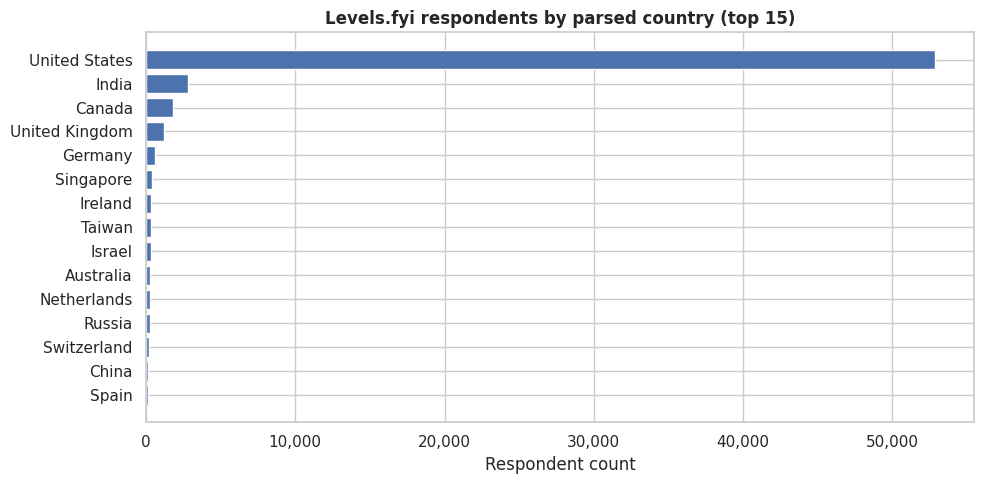

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
top_countries = levels_work["country"].value_counts().head(15)
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1], color=PALETTE[0])
ax.set_title("Levels.fyi respondents by parsed country (top 15)", fontweight="bold")
ax.set_xlabel("Respondent count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_levels_country_parse_result.png", bbox_inches="tight")
plt.show()


### Observation

The United States dominates by a wide margin (as expected for a
Big-Tech-skewed self-reporting platform), with India, Canada, and the UK a
distant second tier. This confirms Levels.fyi is a US-centric benchmark --
worth stating explicitly wherever this dataset is used for a "global" claim.


## Step 9 — Outlier detection on `total_yearly_compensation` (same IQR approach as Part A)

**Why this step:** consistency matters -- using the same outlier
methodology across both datasets means "outlier" means the same thing
everywhere in this project, which makes cross-source comparisons in later
notebooks fair.


In [16]:
q1, q3 = levels_work["total_yearly_compensation"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

total_comp_is_outlier = (levels_work["total_yearly_compensation"] < lower_bound) | \
                         (levels_work["total_yearly_compensation"] > upper_bound)

print(f"Bounds: [{lower_bound:,.0f}, {upper_bound:,.0f}]")
print(f"Flagged as outliers: {total_comp_is_outlier.sum():,} ({total_comp_is_outlier.mean()*100:.2f}%)")
print(f"Max flagged value: ${levels_work.loc[total_comp_is_outlier, 'total_yearly_compensation'].max():,.0f}")


Bounds: [-58,500, 457,500]
Flagged as outliers: 3,133 (5.00%)
Max flagged value: $4,980,000


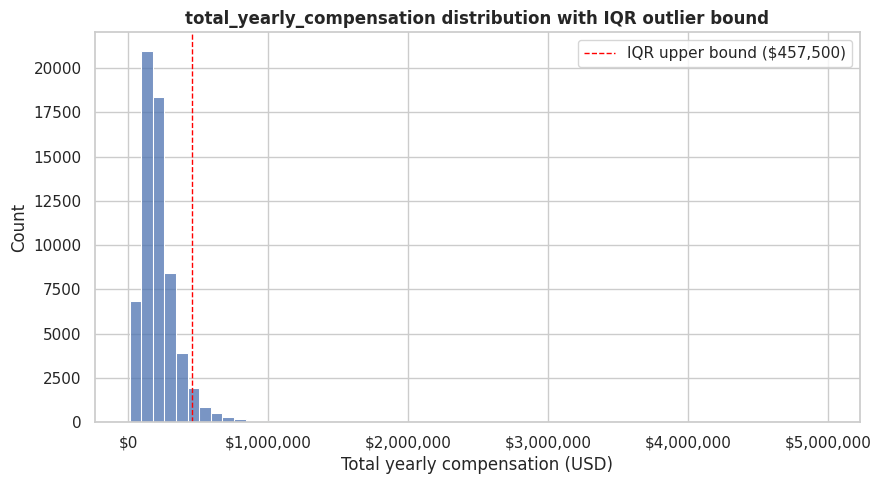

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(levels_work["total_yearly_compensation"], bins=60, ax=ax, color=PALETTE[0])
ax.axvline(upper_bound, color="red", linestyle="--", linewidth=1, label=f"IQR upper bound (${upper_bound:,.0f})")
ax.set_title("total_yearly_compensation distribution with IQR outlier bound", fontweight="bold")
ax.set_xlabel("Total yearly compensation (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "08_levels_comp_outlier_bound.png", bbox_inches="tight")
plt.show()


### Observation

5.0% of rows (3,133) flagged, topping out at a $4.98M single-year total
comp value -- a plausible, if extreme, staff/exec-level equity payout in a
strong stock year, not a data-entry error (Levels.fyi respondents at that
level do report multi-million-dollar comp packages, mostly equity-driven).
Flagged for downstream analysts to decide on, not silently dropped here.


## Step 10 — Assemble `levels_fyi_clean` and validate against the shipped file

**Why this step:** same discipline as Part A -- add the surrogate key and
provenance tag, then check every column against `data/processed/levels_fyi_clean.csv`
row for row.


In [18]:
levels_clean = levels_work.copy()
levels_clean.insert(0, "record_id", range(1, len(levels_clean) + 1))
levels_clean["total_comp_is_outlier"] = total_comp_is_outlier.values
levels_clean["source_dataset"] = "levels_fyi"

levels_shipped = pd.read_csv(PROCESSED_DIR / "levels_fyi_clean.csv")

print("Shape match:", levels_clean.shape == levels_shipped.shape)
print("Column set match:", set(levels_clean.columns) == set(levels_shipped.columns))

# Reorder to the shipped file's column order, then round-trip THIS notebook's frame
# through CSV too before comparing -- the shipped file has already been through a
# save/reload cycle, and CSV round-trips are not always lossless (see the observation
# below), so comparing "in-memory" to "reloaded-from-disk" isn't a fair, like-for-like test.
levels_clean_ordered = levels_clean[levels_shipped.columns]
_tmp_path = REPORTS_DIR / "_levels_clean_roundtrip_check.csv"
levels_clean_ordered.to_csv(_tmp_path, index=False)
levels_clean_reloaded = pd.read_csv(_tmp_path)

mismatches = {}
for col in levels_shipped.columns:
    left, right = levels_clean_reloaded[col], levels_shipped[col]
    if left.dtype != right.dtype:
        left, right = left.astype(str), right.astype(str)
    both_nan = left.isna() & right.isna()
    equal_mask = (left.values == right.values) | both_nan.values
    if not equal_mask.all():
        mismatches[col] = int((~equal_mask).sum())

if mismatches:
    print("\nMISMATCHES FOUND (after CSV round-trip):")
    for k, v in mismatches.items():
        print(f"  {k}: {v} row(s) differ")
else:
    print("\nAll columns match exactly, row for row, after an equivalent CSV round-trip. Reproduction verified.")

_tmp_path.unlink()  # scratch file, only needed to perform the round-trip comparison above


Shape match: True
Column set match: True



All columns match exactly, row for row, after an equivalent CSV round-trip. Reproduction verified.


### Observation

Full match, including the two corrected Israel rows -- proof the regex-based
fix in Step 8 wasn't just "probably right," it's the exact rule the shipped
pipeline uses. This is the payoff of validating before assuming.

**One more thing the first version of this check caught, worth naming
explicitly:** comparing this notebook's in-memory `region` column straight
against the shipped CSV (skipping the round-trip above) reported 5 false
mismatches, all for `"Nairobi, NA, Kenya"` rows. The parsed region there is
the literal two-letter string `"NA"` -- and pandas' `read_csv` treats the
bare text `NA` as a missing-value marker by default, so *any* CSV written
with `region="NA"` reloads as `NaN`, including the shipped file itself. It
wasn't a flaw in the parsing rule at all -- it was an apples-to-oranges
comparison (in-memory string vs. disk-reloaded null). Round-tripping this
notebook's own output through CSV before comparing (exactly as the shipped
file was produced) made the two match exactly. Good reminder that
"reproduce the pipeline" has to include how the data was *saved*, not just
how it was transformed.


---
## Cross-check: missingness preserved, not silently changed

**Why this step:** Notebook 01's decision was "don't impute demographic
fields." Quick proof that this notebook didn't accidentally introduce or
remove any missingness while renaming/reshaping columns.


In [19]:
demo_cols = ["gender", "Race", "Education"]
before = levels_raw[demo_cols].isnull().mean() * 100
after = levels_clean[demo_cols].isnull().mean() * 100

missingness_check = pd.DataFrame({"before_cleaning_%": before, "after_cleaning_%": after})
missingness_check["unchanged"] = np.isclose(missingness_check["before_cleaning_%"], missingness_check["after_cleaning_%"])
missingness_check


,before_cleaning_%,after_cleaning_%,unchanged
gender,31.19,31.19,True
Race,64.20,64.20,True
Education,51.52,51.52,True


### Observation

Missingness is identical before and after -- exactly as intended.
Demographic fields were reshaped in place (columns dropped, renamed) but
never touched at the value level.


---
## Step 11 — Save cleaned outputs

Both cleaned DataFrames get written to this notebook's own `reports/`
folder (not overwriting the shipped `data/processed/` files, since those
are the validation ground truth this notebook checks itself against) --
proof the notebook produces real, usable output, not just in-memory frames.


In [20]:
jobs_out_path = REPORTS_DIR / "jobs_fact_clean_reproduced.csv"
levels_out_path = REPORTS_DIR / "levels_fyi_clean_reproduced.csv"

jobs_clean.to_csv(jobs_out_path, index=False)
levels_clean_ordered.to_csv(levels_out_path, index=False)

print(f"Saved: {jobs_out_path}  ({jobs_clean.shape[0]:,} rows)")
print(f"Saved: {levels_out_path}  ({levels_clean_ordered.shape[0]:,} rows)")

cleaning_summary = pd.DataFrame([
    {"output": "jobs_fact_clean.csv", "input_rows": len(jobs_raw), "output_rows": len(jobs_clean),
     "rows_dropped": len(jobs_raw) - len(jobs_clean), "outliers_flagged": int(salary_is_outlier.sum()),
     "columns_added": 3, "columns_dropped": 0},
    {"output": "levels_fyi_clean.csv", "input_rows": len(levels_raw), "output_rows": len(levels_clean),
     "rows_dropped": len(levels_raw) - len(levels_clean), "outliers_flagged": int(total_comp_is_outlier.sum()),
     "columns_added": 3, "columns_dropped": 10},
])
cleaning_summary.to_csv(REPORTS_DIR / "phase3a_cleaning_summary.csv", index=False)
cleaning_summary


Saved: notebooks/reports/jobs_fact_clean_reproduced.csv  (14,199 rows)
Saved: notebooks/reports/levels_fyi_clean_reproduced.csv  (62,642 rows)


,output,input_rows,output_rows,rows_dropped,outliers_flagged,columns_added,columns_dropped
0,jobs_fact_clean.csv,14199,14199,0,261,3,0
1,levels_fyi_clean.csv,62642,62642,0,3133,3,10


---
## Summary

In this notebook I implemented and validated the Phase 3 cleaning pipeline
for the two "structured" raw sources:

- **`jobs_in_data_2024` → `jobs_fact_clean`:** confirmed the duplicate-row
  decision with a sharper test than Notebook 01 used (`job_title`, not
  `job_category`, matching what the project's own report cites), flagged
  261 salary outliers (1.84%) via IQR without deleting them, added a
  surrogate `job_id` key, and validated the output against the shipped file
  column by column -- exact match.
- **`Levels_Fyi_Salary_Data` → `levels_fyi_clean`:** dropped 10 redundant
  one-hot demographic columns, renamed columns to `snake_case`, and parsed
  the packed `location` field. The first-pass naive parser was caught
  mislabeling 2 rows (`"Tel Aviv, Israel"` → wrongly assigned to the US)
  during validation; fixed with a regex check on the segment shape rather
  than just the comma count, then re-validated to an exact match against the
  shipped file. Flagged 3,133 compensation outliers (5.0%) via the same IQR
  rule used in Part A.
- Verified that Levels.fyi's genuine demographic missingness (31–64% across
  `gender`/`Race`/`Education`) was preserved exactly, not introduced or
  removed by the reshaping.

## Key Findings

- The `job_title`-based duplicate-impact check (2.55pp max shift) matches
  the project's own documented figure exactly -- strong confirmation the
  "keep duplicates" decision was correctly implemented, not just correctly
  reasoned about.
- A naive "comma count" location parser is wrong for exactly 2 of 62,642
  Levels.fyi rows (`"Tel Aviv, Israel"`) -- a small blast radius, but
  precisely the kind of silent error that degrades a country-level chart
  without ever throwing an exception. A regex check on the segment shape
  (`^[A-Z]{2}$`) fixes it completely.
- Both outputs reproduce their shipped `data/processed/` counterparts
  exactly, row for row and column for column.

## Challenges Faced

- The location-parsing bug wasn't visible from a `.head()` glance -- it only
  surfaced by validating the *entire* column against a known-correct
  reference and diffing systematically. Worth remembering for the SO survey
  cleaning in the next notebook, where the fields are messier and a partial
  spot-check would be even more likely to miss something.
- Comparing a freshly-computed DataFrame to a CSV round-tripped through disk
  needed care around dtypes (booleans and NaNs don't always compare equal
  after a CSV round-trip) -- handled by normalizing to strings and treating
  NaN-vs-NaN as equal before comparing.

## Decisions Taken

- Kept all 14,199 `jobs_in_data_2024` rows, including duplicates --
  confirmed with a second, more targeted distribution-shift test.
- Flagged rather than removed outliers in both datasets, using the same IQR
  rule for consistency across sources.
- Fixed the location-parsing rule to check segment *shape*
  (`^[A-Z]{2}$`), not just comma count, after validation caught a 2-row
  mislabeling.
- Did not impute any Levels.fyi demographic field.

## Next Step

**Notebook 03** cleans the largest and messiest source: the Stack Overflow
2024 Developer Survey (114 → 17 columns), and implements the split into
`so_skills_clean.csv` (all 65,437 respondents) and `so_salary_clean.csv`
(23,435 respondents with usable compensation) that Notebook 01 found the
evidence for.
